#  Predicción de Compras de Nuevos Ítems de Moda
---
**Proyecto:** Predecir si un cliente existente comprará un nuevo ítem de moda dentro de los 60 días posteriores a su lanzamiento.  
**Fecha de referencia:** 14 de mayo de 2026  
**Problema:** Cold-start — los ítems del conjunto de test fueron lanzados **después** de esta fecha y no tienen historial de compra.

---


## 0. Configuración e Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Estilo global ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
PALETTE = sns.color_palette('muted')
CURRENT_DATE = pd.Timestamp('2026-05-14')

# ── Rutas de archivos ──────────────────────────────────────────────────────────
TRAIN_PATH = 'customer_purchases_train.csv'
TEST_PATH  = 'customer_purchases_test.csv'

print("Librerías cargadas correctamente ✓")
print(f"Fecha de referencia del proyecto: {CURRENT_DATE.date()}")


Librerías cargadas correctamente ✓
Fecha de referencia del proyecto: 2026-05-14


## 1. Carga y Revisión Inicial de Datos

Cargamos los dos datasets en su forma cruda para inspeccionarlos antes de cualquier transformación.


In [5]:
# ── Carga de datos ─────────────────────────────────────────────────────────────
train_raw = pd.read_csv(r"C:\Users\sergi\Downloads\ml26_Gurts\src\ml26\datasets\customer_purchases\customer_purchases_train.csv")
test_raw  = pd.read_csv(r"C:\Users\sergi\Downloads\ml26_Gurts\src\ml26\datasets\customer_purchases\customer_purchases_test.csv")

print("=" * 60)
print(f"  TRAIN shape : {train_raw.shape[0]:,} filas × {train_raw.shape[1]} columnas")
print(f"  TEST  shape : {test_raw.shape[0]:,} filas × {test_raw.shape[1]} columnas")
print("=" * 60)


  TRAIN shape : 6,892 filas × 18 columnas
  TEST  shape : 4,719 filas × 17 columnas


In [6]:
# ── Primeras filas — Train ─────────────────────────────────────────────────────
print("### TRAIN — primeras 5 filas ###")
train_raw.head()


### TRAIN — primeras 5 filas ###


,purchase_id,customer_id,customer_date_of_birth,customer_gender,customer_signup_date,item_id,item_title,item_category,item_price,item_img_filename,item_avg_rating,item_num_ratings,item_release_date,purchase_timestamp,customer_item_views,purchase_item_rating,purchase_device,label
0,0,CUST_0094,03/05/1996,female,07/02/2025,ITEM_0101,Exclusive Premium Blouse Collection,blouse,1310.13,ITEM_0101.png,3.50,28,16/12/2024,07/02/2025,5,NaN,mobile,1
1,1,CUST_0279,05/02/1974,female,03/02/2025,ITEM_0311,Casual Jeans That Stands Out,jeans,1406.33,ITEM_0311.png,3.40,48,19/03/2024,08/02/2025,3,NaN,desktop,1
2,2,CUST_0775,09/10/1954,male,01/02/2025,ITEM_0752,Stylish Blouse For Every Occasion,blouse,2356.83,ITEM_0752.png,3.73,19,03/02/2025,12/02/2025,6,NaN,desktop,1
3,3,CUST_0722,05/07/1963,male,13/02/2025,ITEM_0698,Modern Shoes Must Have,shoes,2086.32,ITEM_0698.png,3.49,33,02/02/2025,13/02/2025,11,NaN,desktop,1
4,4,CUST_0741,07/08/1957,female,22/01/2025,ITEM_0698,Modern Shoes Must Have,shoes,2086.32,ITEM_0698.png,3.49,33,02/02/2025,17/02/2025,6,NaN,desktop,1


In [7]:
# ── Primeras filas — Test ──────────────────────────────────────────────────────
print("### TEST — primeras 5 filas ###")
test_raw.head()


### TEST — primeras 5 filas ###


,purchase_id,customer_id,customer_date_of_birth,customer_gender,customer_signup_date,item_id,item_title,item_category,item_price,item_img_filename,item_avg_rating,item_num_ratings,item_release_date,purchase_timestamp,customer_item_views,purchase_item_rating,purchase_device
0,6892,CUST_0188,1998-07-20,NaN,2026-03-03,ITEM_0142,Exclusive Stylish Dress Collection,dress,1296.81,ITEM_0142.png,NaN,NaN,2026-05-15,NaN,NaN,NaN,NaN
1,6893,CUST_0394,1973-07-14,male,2025-09-10,ITEM_0641,Step Up Your Style With Modern Slacks,slacks,1811.93,ITEM_0641.png,NaN,NaN,2026-05-15,NaN,NaN,NaN,NaN
2,6894,CUST_0081,2000-12-02,female,2025-08-08,ITEM_0142,Exclusive Stylish Dress Collection,dress,1296.81,ITEM_0142.png,NaN,NaN,2026-05-15,NaN,NaN,NaN,NaN
3,6895,CUST_0480,1986-09-14,male,2025-02-06,ITEM_0142,Exclusive Stylish Dress Collection,dress,1296.81,ITEM_0142.png,NaN,NaN,2026-05-15,NaN,NaN,NaN,NaN
4,6896,CUST_0166,2003-04-12,NaN,2025-07-28,ITEM_0412,Durable Jeans For Every Occasion,jeans,434.27,ITEM_0412.png,NaN,NaN,2026-05-15,NaN,NaN,NaN,NaN


In [8]:
# ── Tipos de datos y nulos rápidos ─────────────────────────────────────────────
def dataset_info(df, name):
    """Resumen compacto de tipos, nulos y valores únicos."""
    info = pd.DataFrame({
        'dtype'  : df.dtypes.astype(str),
        'non_null': df.notnull().sum(),
        'null'   : df.isnull().sum(),
        'null_%' : (df.isnull().mean() * 100).round(2),
        'nunique': df.nunique(),
        'sample' : [df[c].dropna().iloc[0] if df[c].notna().any() else 'N/A' for c in df.columns]
    })
    print(f"\n{'='*60}\n  {name}\n{'='*60}")
    display(info)

dataset_info(train_raw, "TRAIN")
dataset_info(test_raw,  "TEST")



  TRAIN


,dtype,non_null,null,null_%,nunique,sample
purchase_id,int64,6892,0,0.00,6892,0
customer_id,str,6892,0,0.00,779,CUST_0094
customer_date_of_birth,str,6892,0,0.00,769,03/05/1996
customer_gender,str,5428,1464,21.24,2,female
customer_signup_date,str,6892,0,0.00,394,07/02/2025
item_id,str,6892,0,0.00,485,ITEM_0101
item_title,str,6892,0,0.00,245,Exclusive Premium Blouse Collection
item_category,str,6892,0,0.00,10,blouse
item_price,float64,6892,0,0.00,462,1310.13
item_img_filename,str,6892,0,0.00,485,ITEM_0101.png



  TEST


,dtype,non_null,null,null_%,nunique,sample
purchase_id,int64,4719,0,0.0,4719,6892
customer_id,str,4719,0,0.0,779,CUST_0188
customer_date_of_birth,str,4719,0,0.0,769,1998-07-20
customer_gender,str,3728,991,21.0,2,male
customer_signup_date,str,4719,0,0.0,394,2026-03-03
item_id,str,4719,0,0.0,144,ITEM_0142
item_title,str,4719,0,0.0,117,Exclusive Stylish Dress Collection
item_category,str,4719,0,0.0,10,dress
item_price,float64,4719,0,0.0,143,1296.81
item_img_filename,str,4719,0,0.0,144,ITEM_0142.png


### 📋 Observaciones iniciales

| # | Hallazgo |
|---|----------|
| 1 | **Train** tiene 6 892 registros; **Test** tiene 4 719. |
| 2 | Todas las columnas existen en ambos sets salvo `label` (solo en train). |
| 3 | Las fechas en **train** usan formato `DD/MM/YYYY`; en **test** usan `YYYY-MM-DD`. |
| 4 | En test, columnas operacionales (`purchase_timestamp`, `customer_item_views`, `purchase_device`, `item_avg_rating`, `item_num_ratings`, `purchase_item_rating`) son **todas NaN** — consecuencia directa del cold-start. |
| 5 | `label` en train **siempre es 1**: el dataset solo contiene compras realizadas (ejemplos positivos). Esto requiere generar ejemplos negativos en el proceso de modelado. |
| 6 | `customer_gender` tiene ~21 % de valores faltantes en ambos sets. |
| 7 | `purchase_item_rating` tiene ~80 % de nulos en train — la mayoría de compradores no dejó reseña. |


## 2. Valores Faltantes — Análisis y Tratamiento


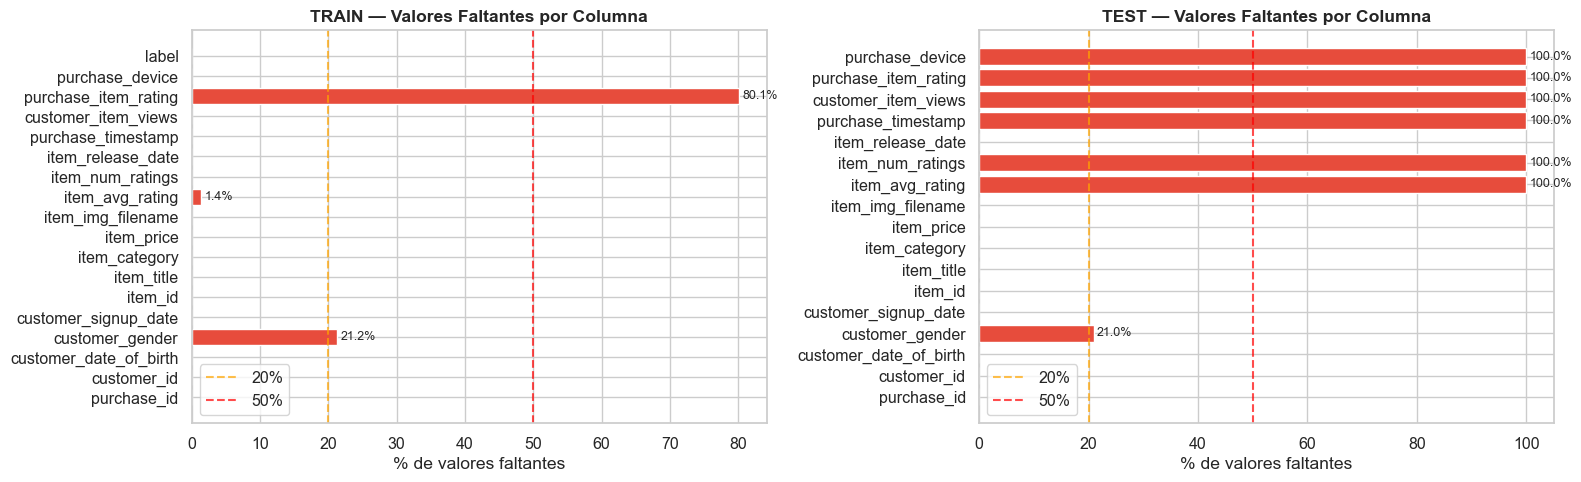

Figura guardada: missing_values.png


In [9]:
# ── Heatmap de missing values ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (df, title) in zip(axes, [(train_raw, 'TRAIN'), (test_raw, 'TEST')]):
    missing_pct = df.isnull().mean() * 100
    colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in missing_pct]
    bars = ax.barh(missing_pct.index, missing_pct.values, color=colors)
    ax.set_xlabel('% de valores faltantes')
    ax.set_title(f'{title} — Valores Faltantes por Columna', fontweight='bold')
    ax.axvline(x=20, color='orange', linestyle='--', alpha=0.7, label='20%')
    ax.axvline(x=50, color='red',    linestyle='--', alpha=0.7, label='50%')
    for bar, val in zip(bars, missing_pct.values):
        if val > 0:
            ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontsize=9)
    ax.legend()

plt.tight_layout()
plt.savefig('missing_values.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figura guardada: missing_values.png")


In [10]:
# ── Tabla consolidada de missing ───────────────────────────────────────────────
def missing_report(train, test):
    cols = train.columns.tolist()
    report = pd.DataFrame({
        'columna'     : cols,
        'train_null_%': [round(train[c].isnull().mean()*100,2) if c in train else None for c in cols],
        'test_null_%' : [round(test[c].isnull().mean()*100,2)  if c in test  else None for c in cols],
    })
    report['causa_probable'] = report['columna'].map({
        'customer_gender'    : 'Dato opcional en registro / privacidad',
        'item_avg_rating'    : 'Ítems sin reseñas aún (train) / cold-start (test)',
        'item_num_ratings'   : 'Cold-start: ítem nuevo sin historial',
        'purchase_timestamp' : 'Cold-start: compra aún no ocurrida',
        'customer_item_views': 'Cold-start: interacción aún no registrada',
        'purchase_item_rating':'La mayoría de compradores no deja reseña (~80 %)',
        'purchase_device'    : 'Cold-start: dispositivo desconocido',
    }).fillna('—')
    return report.sort_values('train_null_%', ascending=False)

display(missing_report(train_raw, test_raw))


,columna,train_null_%,test_null_%,causa_probable
15,purchase_item_rating,80.12,100.0,La mayoría de compradores no deja reseña (~80 %)
3,customer_gender,21.24,21.0,Dato opcional en registro / privacidad
10,item_avg_rating,1.36,100.0,Ítems sin reseñas aún (train) / cold-start (test)
0,purchase_id,0.00,0.0,—
1,customer_id,0.00,0.0,—
2,customer_date_of_birth,0.00,0.0,—
6,item_title,0.00,0.0,—
7,item_category,0.00,0.0,—
4,customer_signup_date,0.00,0.0,—
5,item_id,0.00,0.0,—


### 🔧 Decisiones de imputación

| Columna | % Nulo (train) | Estrategia | Justificación |
|---------|---------------|------------|---------------|
| `customer_gender` | 21 % | Imputar con `'Unknown'` | Es variable categórica; imputar con moda introduciría sesgo al ser ~50/50 male/female. `'Unknown'` preserva la información de ausencia. |
| `item_avg_rating` | 1.4 % | Imputar con **mediana** por `item_category` | Pocos nulos, escala 1-5 con distribución sesgada; la mediana es más robusta que la media. |
| `purchase_item_rating` | 80 % | **No imputar** — crear flag binario `has_rated` | Imputar un rating que no existe distorsiona el comportamiento. El flag captura la señal (¿dejó reseña?). |
| `item_num_ratings` (test) | 100 % | Dejar como `0` o `NaN` | Cold-start genuino; no existe historial al momento de la predicción. |
| Columnas operacionales (test) | 100 % | Dejar como `NaN` | Son consecuencia directa del cold-start; se usarán features derivadas del historial del cliente. |


## 3. Limpieza y Preparación de Datos


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Establecer la fecha actual de referencia
CURRENT_DATE = pd.Timestamp('2026-05-14')

# ── Función de limpieza reutilizable ───────────────────────────────────────────
def clean_dataset(df, name='df'):
    """Aplica toda la pipeline de limpieza y devuelve un DataFrame limpio."""
    df = df.copy()

    # 1. Parseo de fechas (train: DD/MM/YYYY | test: YYYY-MM-DD)
    date_cols_train = ['customer_date_of_birth', 'customer_signup_date',
                       'item_release_date', 'purchase_timestamp']
    for col in date_cols_train:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')

    # 2. Feature: edad del cliente
    if 'customer_date_of_birth' in df.columns:
        df['customer_age'] = ((CURRENT_DATE - df['customer_date_of_birth'])
                              .dt.days // 365).astype('Int64')

    # 3. Feature: antigüedad del cliente (días desde signup)
    if 'customer_signup_date' in df.columns:
        df['customer_tenure_days'] = (CURRENT_DATE - df['customer_signup_date']).dt.days

    # 4. Feature: días desde lanzamiento del ítem hasta la compra (solo train)
    if 'item_release_date' in df.columns and 'purchase_timestamp' in df.columns:
        df['days_since_release'] = (df['purchase_timestamp'] - df['item_release_date']).dt.days

    # 5. Features temporales de compra (solo train)
    if 'purchase_timestamp' in df.columns:
        df['purchase_year']    = df['purchase_timestamp'].dt.year
        df['purchase_month']   = df['purchase_timestamp'].dt.month
        df['purchase_dayofweek'] = df['purchase_timestamp'].dt.dayofweek  # 0=lunes

    # 6. Imputar customer_gender → 'Unknown'
    df['customer_gender'] = df['customer_gender'].fillna('Unknown')

    # 7. Imputar item_avg_rating con mediana por categoría
    if df['item_avg_rating'].isnull().any():
        med = df.groupby('item_category')['item_avg_rating'].transform('median')
        df['item_avg_rating'] = df['item_avg_rating'].fillna(med)

    # 8. Flag: si el cliente dejó rating
    df['has_rated'] = df['purchase_item_rating'].notna().astype(int)

    # 9. Normalizar strings categóricos (strip + lowercase)
    for col in ['customer_gender', 'item_category', 'purchase_device']:
        if col in df.columns:
            # Explicitly handle NaNs for 'purchase_device' in test set
            if col == 'purchase_device':
                df[col] = df[col].fillna('unknown')
            # Ensure the column is string type before applying string methods
            df[col] = df[col].astype(str).str.strip().str.lower()

    print(f"✓ {name} limpiado — shape: {df.shape}")
    print(f"  Nulos restantes: {df.isnull().sum()[df.isnull().sum()>0].to_dict()}")
    return df

train = clean_dataset(train_raw, 'TRAIN')
test  = clean_dataset(test_raw,  'TEST')


✓ TRAIN limpiado — shape: (6892, 25)
  Nulos restantes: {'purchase_item_rating': 5522}
✓ TEST limpiado — shape: (4719, 24)
  Nulos restantes: {'customer_signup_date': 2904, 'item_avg_rating': 4719, 'item_num_ratings': 4719, 'purchase_timestamp': 4719, 'customer_item_views': 4719, 'purchase_item_rating': 4719, 'customer_tenure_days': 2904, 'days_since_release': 4719, 'purchase_year': 4719, 'purchase_month': 4719, 'purchase_dayofweek': 4719}


In [12]:
# ── Verificación de duplicados ─────────────────────────────────────────────────
print(f"Duplicados en TRAIN : {train.duplicated().sum()}")
print(f"Duplicados en TEST  : {test.duplicated().sum()}")
print()

# ── Integridad: clientes comunes ───────────────────────────────────────────────
common_customers = set(train['customer_id']) & set(test['customer_id'])
only_train = set(train['customer_id']) - set(test['customer_id'])
only_test  = set(test['customer_id'])  - set(train['customer_id'])

print(f"Clientes únicos en TRAIN : {train['customer_id'].nunique():,}")
print(f"Clientes únicos en TEST  : {test['customer_id'].nunique():,}")
print(f"Clientes en ambos        : {len(common_customers):,}")
print(f"Solo en TRAIN            : {len(only_train):,}")
print(f"Solo en TEST             : {len(only_test):,}")
print()

# ── Integridad: ítems ──────────────────────────────────────────────────────────
overlap_items = set(train['item_id']) & set(test['item_id'])
print(f"Ítems únicos en TRAIN    : {train['item_id'].nunique():,}")
print(f"Ítems únicos en TEST     : {test['item_id'].nunique():,}")
print(f"Ítems en ambos sets      : {len(overlap_items):,}  ← COLD-START confirmado")


Duplicados en TRAIN : 0


Duplicados en TEST  : 0

Clientes únicos en TRAIN : 779
Clientes únicos en TEST  : 779
Clientes en ambos        : 779
Solo en TRAIN            : 0
Solo en TEST             : 0

Ítems únicos en TRAIN    : 485
Ítems únicos en TEST     : 144
Ítems en ambos sets      : 0  ← COLD-START confirmado


### ✅ Validaciones de integridad

- **Sin duplicados** en ningún dataset.
- **Todos los clientes de test aparecen en train** → tenemos historial de compras de cada cliente. Esto es clave para construir features de comportamiento.
- **Ningún ítem de test existe en train** → Cold-start puro: los ítems no tienen historial de compras previas.
- Las fechas de `item_release_date` en test son **2026-05-15 o posteriores**, confirmando que son lanzamientos futuros.


## 4. Análisis Univariado

Estudiamos la distribución de cada variable relevante de forma independiente.


In [13]:
# ── 4.1 Variable objetivo ──────────────────────────────────────────────────────
print("NOTA IMPORTANTE sobre el label:")
print("="*60)
print(f"Valores únicos de 'label' en train: {train['label'].unique()}")
print()
print("El dataset de training contiene ÚNICAMENTE compras realizadas (label=1).")
print("Para entrenar un clasificador binario, será necesario generar ejemplos")
print("negativos (pares cliente-ítem sin compra) mediante negative sampling.")
print("Esto es una característica común en sistemas de recomendación.")


NOTA IMPORTANTE sobre el label:
Valores únicos de 'label' en train: [1]

El dataset de training contiene ÚNICAMENTE compras realizadas (label=1).
Para entrenar un clasificador binario, será necesario generar ejemplos
negativos (pares cliente-ítem sin compra) mediante negative sampling.
Esto es una característica común en sistemas de recomendación.


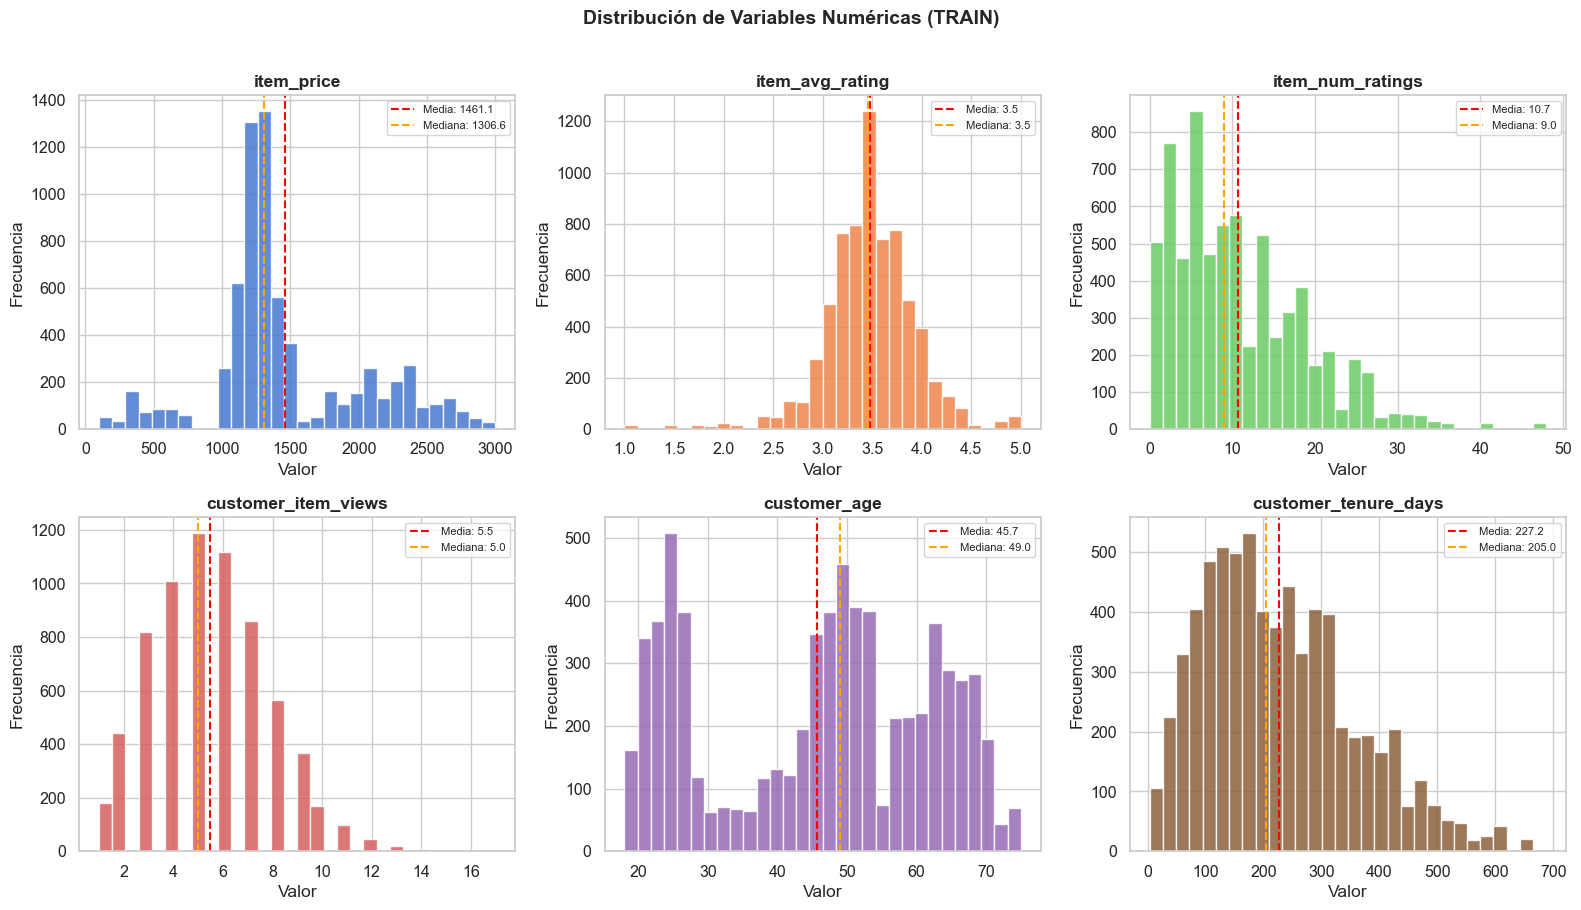

In [14]:
# ── 4.2 Variables numéricas: distribuciones ────────────────────────────────────
num_cols = ['item_price', 'item_avg_rating', 'item_num_ratings',
            'customer_item_views', 'customer_age', 'customer_tenure_days']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = train[col].dropna()
    axes[i].hist(data, bins=30, color=PALETTE[i % len(PALETTE)], edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Media: {data.mean():.1f}')
    axes[i].axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {data.median():.1f}')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución de Variables Numéricas (TRAIN)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('univariate_numeric.png', dpi=120, bbox_inches='tight')
plt.show()


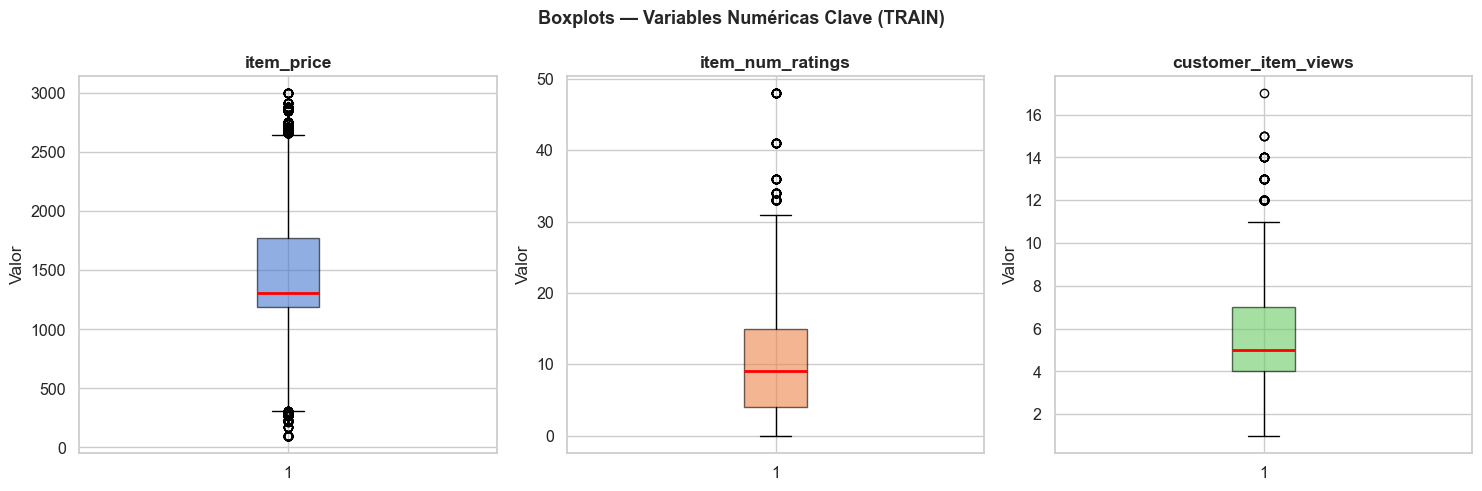

In [15]:
# ── 4.3 Boxplots — detección visual de outliers ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, color in zip(axes,
                           ['item_price', 'item_num_ratings', 'customer_item_views'],
                           [PALETTE[0], PALETTE[1], PALETTE[2]]):
    ax.boxplot(train[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Valor')

plt.suptitle('Boxplots — Variables Numéricas Clave (TRAIN)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_numeric.png', dpi=120, bbox_inches='tight')
plt.show()


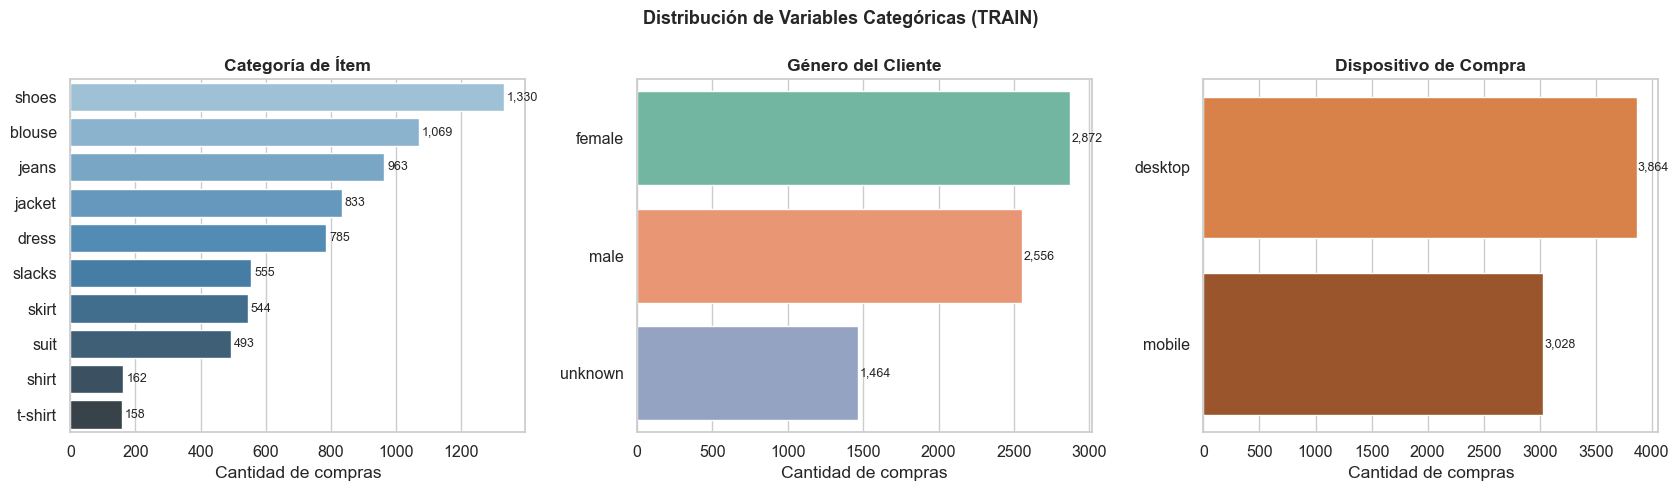

In [16]:
# ── 4.4 Variables categóricas ──────────────────────────────────────────────────
cat_cols = ['item_category', 'customer_gender', 'purchase_device']
labels   = ['Categoría de Ítem', 'Género del Cliente', 'Dispositivo de Compra']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, col, label, palette in zip(axes, cat_cols, labels,
                                    ['Blues_d', 'Set2', 'Oranges_d']):
    counts = train[col].value_counts()
    sns.barplot(x=counts.values, y=counts.index, ax=ax, palette=palette)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Cantidad de compras')
    ax.set_ylabel('')
    for p, v in zip(ax.patches, counts.values):
        ax.text(p.get_width() + 10, p.get_y() + p.get_height()/2,
                f'{v:,}', va='center', fontsize=9)

plt.suptitle('Distribución de Variables Categóricas (TRAIN)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=120, bbox_inches='tight')
plt.show()


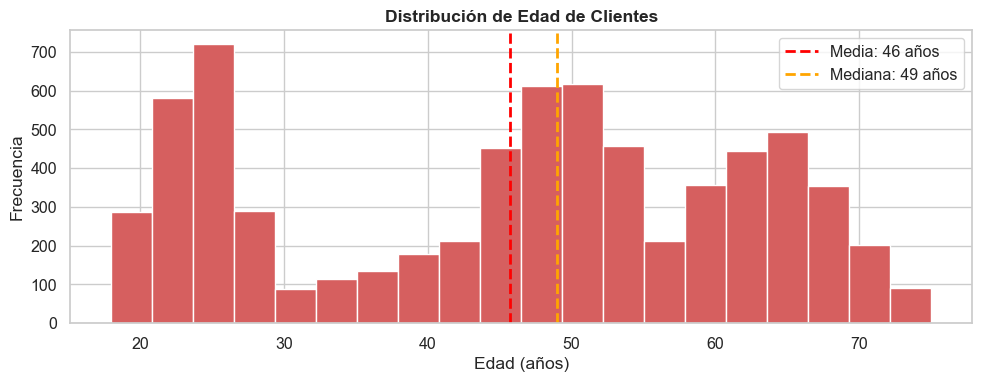


Estadísticas de edad:
count    6892.0
mean       45.7
std        16.3
min        18.0
25%        27.0
50%        49.0
75%        59.0
max        75.0
Name: customer_age, dtype: Float64


In [17]:
# ── 4.5 Edad del cliente ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
train['customer_age'].hist(bins=20, color=PALETTE[3], edgecolor='white', ax=ax)
ax.axvline(train['customer_age'].mean(),   color='red',    ls='--', lw=2, label=f"Media: {train['customer_age'].mean():.0f} años")
ax.axvline(train['customer_age'].median(), color='orange', ls='--', lw=2, label=f"Mediana: {train['customer_age'].median():.0f} años")
ax.set_title('Distribución de Edad de Clientes', fontweight='bold')
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.savefig('age_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nEstadísticas de edad:")
print(train['customer_age'].describe().round(1))


### 📊 Interpretaciones univariadas

**Precio (`item_price`):** Rango de $100 a $3 000, con media ≈ $1 461. La distribución muestra una cola larga hacia precios altos; la mayoría de compras se concentran entre $1 000 y $1 800.

**Rating promedio del ítem (`item_avg_rating`):** Concentrado entre 3.0 y 4.5 sobre 5. Muy pocos ítems tienen calificaciones extremas, lo que sugiere una distribución de ratings relativamente consistente.

**Vistas del ítem (`customer_item_views`):** Distribución casi normal centrada en 5 vistas. Sugiere que los clientes exploran los ítems brevemente antes de comprar.

**Categorías:** `shoes` es la categoría más comprada (1 330), seguida de `blouse` (1 069) y `jeans` (963). `t-shirt` y `shirt` tienen menor representación.

**Género:** Casi equitativo entre female (42 %) y male (37 %), con 21 % `Unknown`.

**Edad:** Distribución bimodal con picos alrededor de ~25-30 y ~55-60 años. El rango va de 18 a 75 años.


## 5. Análisis Bivariado y Multivariado


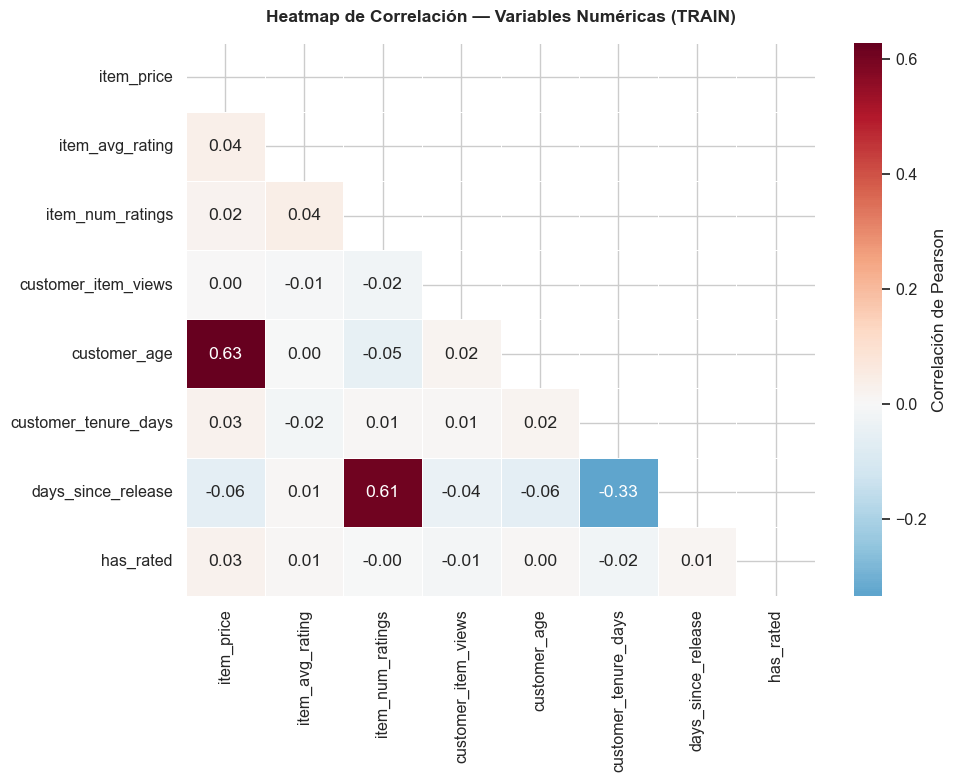

In [18]:
# ── 5.1 Correlación entre variables numéricas ──────────────────────────────────
num_for_corr = ['item_price', 'item_avg_rating', 'item_num_ratings',
                'customer_item_views', 'customer_age', 'customer_tenure_days',
                'days_since_release', 'has_rated']

corr = train[num_for_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Correlación de Pearson'})
ax.set_title('Heatmap de Correlación — Variables Numéricas (TRAIN)',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


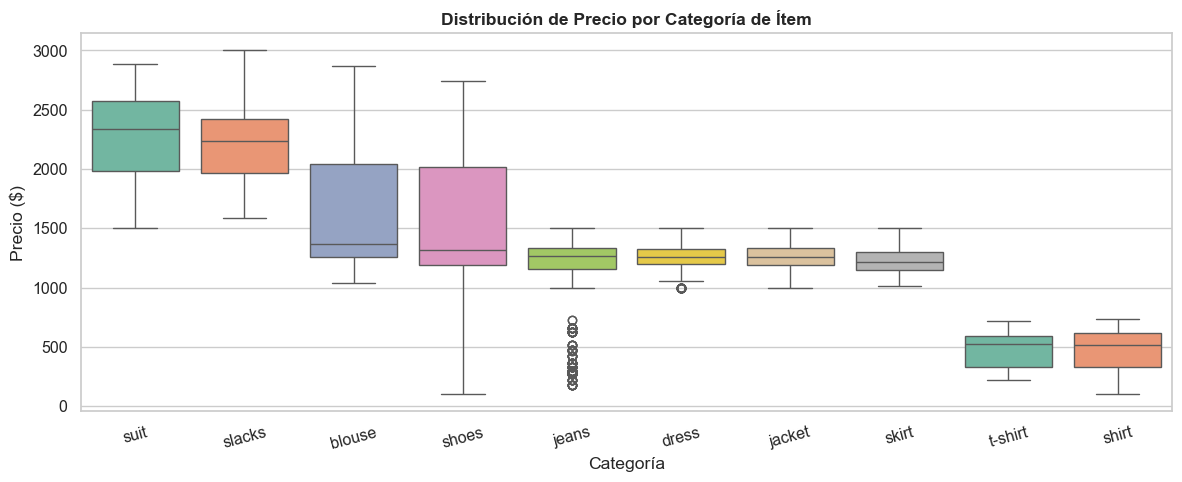

In [19]:
# ── 5.2 Precio por categoría de ítem ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
order = train.groupby('item_category')['item_price'].median().sort_values(ascending=False).index
sns.boxplot(data=train, x='item_category', y='item_price', order=order,
            palette='Set2', ax=ax)
ax.set_title('Distribución de Precio por Categoría de Ítem', fontweight='bold')
ax.set_xlabel('Categoría')
ax.set_ylabel('Precio ($)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('price_by_category.png', dpi=120, bbox_inches='tight')
plt.show()


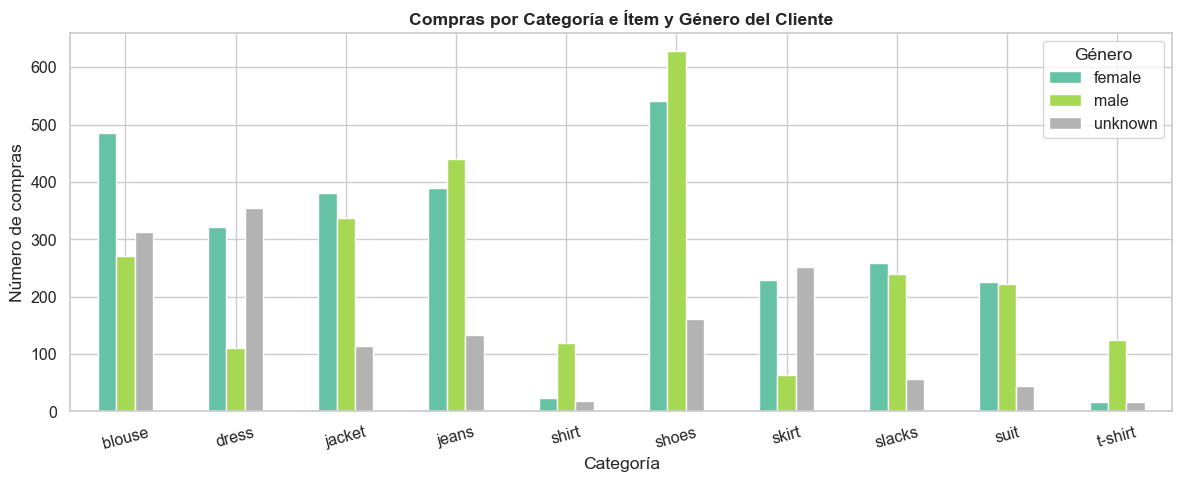

In [20]:
# ── 5.3 Compras por categoría y género ─────────────────────────────────────────
pivot = train.groupby(['item_category', 'customer_gender']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
pivot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
ax.set_title('Compras por Categoría e Ítem y Género del Cliente', fontweight='bold')
ax.set_xlabel('Categoría')
ax.set_ylabel('Número de compras')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Género', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('category_by_gender.png', dpi=120, bbox_inches='tight')
plt.show()


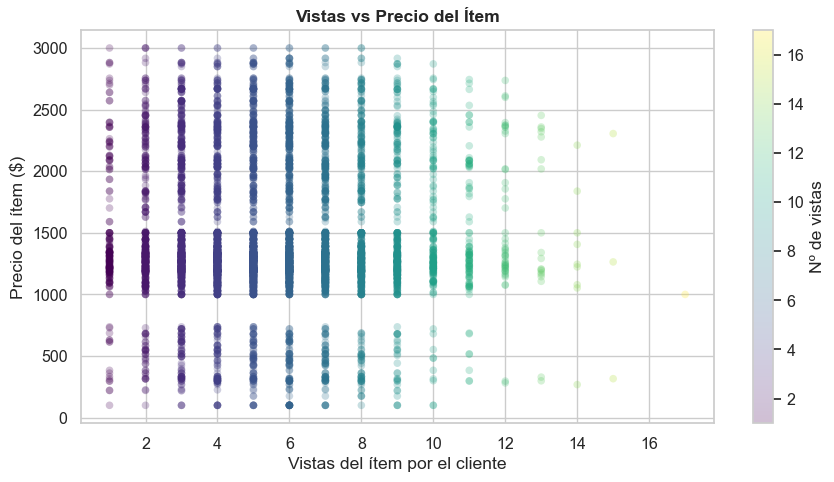

Correlación Pearson (vistas vs precio): 0.002


In [21]:
# ── 5.4 Vistas vs Precio (scatter) ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(train['customer_item_views'], train['item_price'],
                alpha=0.25, c=train['customer_item_views'],
                cmap='viridis', edgecolors='none', s=30)
plt.colorbar(sc, ax=ax, label='Nº de vistas')
ax.set_xlabel('Vistas del ítem por el cliente')
ax.set_ylabel('Precio del ítem ($)')
ax.set_title('Vistas vs Precio del Ítem', fontweight='bold')
plt.tight_layout()
plt.savefig('views_vs_price.png', dpi=120, bbox_inches='tight')
plt.show()

corr_val = train[['customer_item_views', 'item_price']].corr().iloc[0, 1]
print(f"Correlación Pearson (vistas vs precio): {corr_val:.3f}")


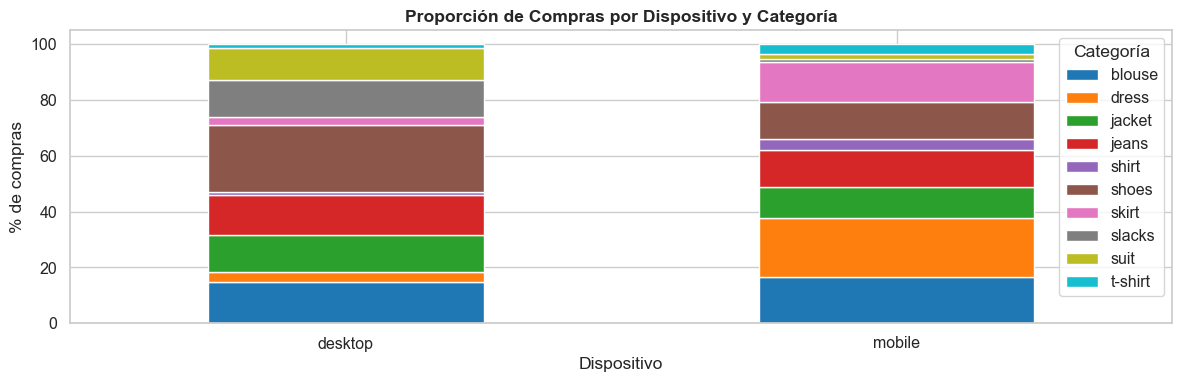

In [22]:
# ── 5.5 Compras por dispositivo y categoría ────────────────────────────────────
device_cat = train.groupby(['purchase_device', 'item_category']).size().unstack(fill_value=0)
device_cat_pct = device_cat.div(device_cat.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 4))
device_cat_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Proporción de Compras por Dispositivo y Categoría', fontweight='bold')
ax.set_xlabel('Dispositivo')
ax.set_ylabel('% de compras')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Categoría', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('device_by_category.png', dpi=120, bbox_inches='tight')
plt.show()


### 📊 Interpretaciones bivariadas

- **Correlaciones numéricas:** Las correlaciones entre variables son en su mayoría bajas (< 0.2), lo que sugiere que cada feature aporta información independiente. No hay multicolinealidad severa.
- **Precio por categoría:** `suit` y `jacket` tienen los precios medianos más altos. `shoes` muestra mayor varianza en precio.
- **Género y categoría:** `blouse` y `skirt` son predominantemente comprados por mujeres; `jeans` y `shoes` tienen distribución más equitativa.
- **Vistas vs Precio:** Correlación débil — el número de vistas antes de comprar no está fuertemente relacionado con el precio del ítem.
- **Dispositivo:** La distribución de categorías compradas es muy similar entre desktop y mobile, sin preferencias marcadas.


## 6. Análisis Temporal

El tiempo es una dimensión crítica en este problema: la predicción se hace para los **60 días posteriores al lanzamiento** de un ítem.


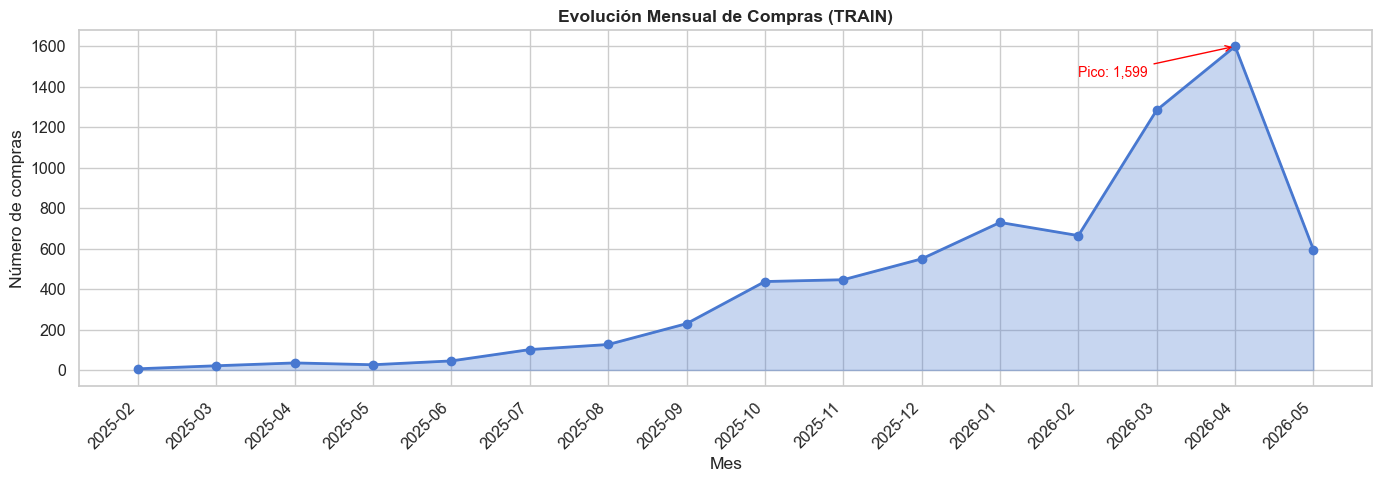

In [23]:
# ── 6.1 Evolución mensual de compras ───────────────────────────────────────────
monthly = train.groupby(train['purchase_timestamp'].dt.to_period('M')).size().reset_index()
monthly.columns = ['month', 'purchases']
monthly['month_str'] = monthly['month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(range(len(monthly)), monthly['purchases'], alpha=0.3, color=PALETTE[0])
ax.plot(range(len(monthly)), monthly['purchases'], marker='o', color=PALETTE[0], linewidth=2)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['month_str'], rotation=45, ha='right')
ax.set_title('Evolución Mensual de Compras (TRAIN)', fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Número de compras')

# Anotar el pico
peak_idx = monthly['purchases'].idxmax()
ax.annotate(f"Pico: {monthly.loc[peak_idx,'purchases']:,}",
            xy=(peak_idx, monthly.loc[peak_idx,'purchases']),
            xytext=(peak_idx - 2, monthly.loc[peak_idx,'purchases'] - 150),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=10)

plt.tight_layout()
plt.savefig('monthly_purchases.png', dpi=120, bbox_inches='tight')
plt.show()


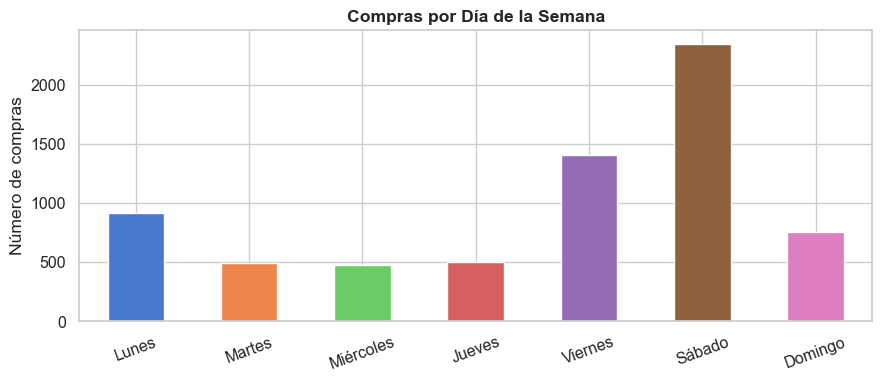

In [24]:
# ── 6.2 Compras por día de la semana ───────────────────────────────────────────
day_names = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
dow = train.groupby('purchase_dayofweek').size()
dow.index = [day_names[i] for i in dow.index]

fig, ax = plt.subplots(figsize=(9, 4))
dow.plot(kind='bar', ax=ax, color=PALETTE[:7], edgecolor='white')
ax.set_title('Compras por Día de la Semana', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Número de compras')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('purchases_dayofweek.png', dpi=120, bbox_inches='tight')
plt.show()


Porcentaje de compras ocurridas dentro de los primeros 60 días: 72.2%


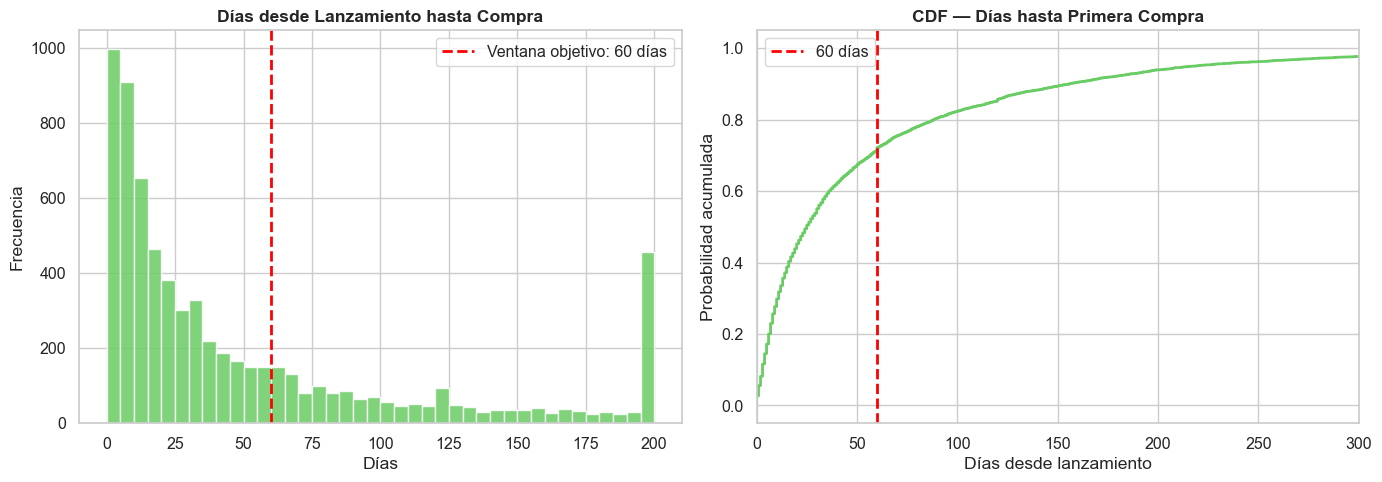

In [25]:
# ── 6.3 Días desde lanzamiento hasta compra ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(train['days_since_release'].clip(0, 200), bins=40,
             color=PALETTE[2], edgecolor='white', alpha=0.85)
axes[0].axvline(60, color='red', ls='--', lw=2, label='Ventana objetivo: 60 días')
axes[0].set_title('Días desde Lanzamiento hasta Compra', fontweight='bold')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# CDF
sorted_days = np.sort(train['days_since_release'].dropna())
cdf = np.arange(1, len(sorted_days)+1) / len(sorted_days)
axes[1].plot(sorted_days, cdf, color=PALETTE[2], linewidth=2)
axes[1].axvline(60, color='red', ls='--', lw=2, label='60 días')
axes[1].set_xlim(0, 300)
axes[1].set_title('CDF — Días hasta Primera Compra', fontweight='bold')
axes[1].set_xlabel('Días desde lanzamiento')
axes[1].set_ylabel('Probabilidad acumulada')
axes[1].legend()

pct_within_60 = (train['days_since_release'] <= 60).mean() * 100
print(f"Porcentaje de compras ocurridas dentro de los primeros 60 días: {pct_within_60:.1f}%")

plt.tight_layout()
plt.savefig('days_since_release.png', dpi=120, bbox_inches='tight')
plt.show()


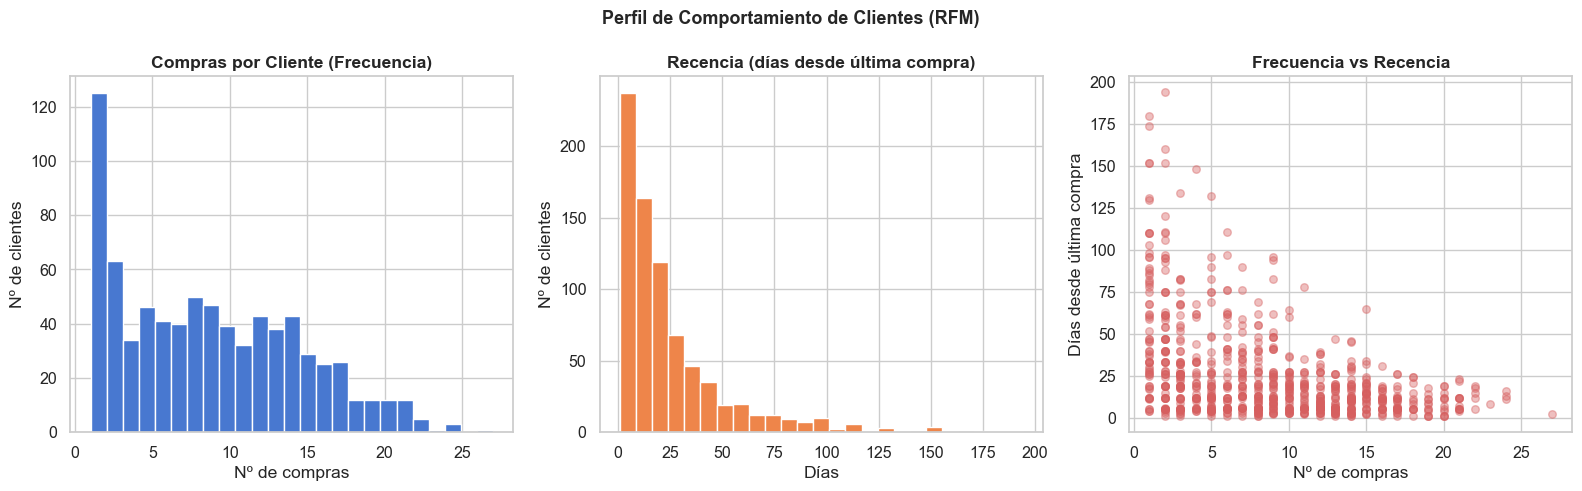


Estadísticas de frecuencia de compras por cliente:
count    779.0
mean       8.8
std        5.7
min        1.0
25%        4.0
50%        8.0
75%       13.0
max       27.0
Name: num_purchases, dtype: float64

Clientes con ≥ 10 compras: 333 (42.7%)
Clientes con recencia < 30 días: 581 (74.6%)


In [26]:
# ── 6.4 Recencia y frecuencia de compra por cliente ────────────────────────────
client_stats = train.groupby('customer_id').agg(
    num_purchases    = ('purchase_id', 'count'),
    last_purchase    = ('purchase_timestamp', 'max'),
    first_purchase   = ('purchase_timestamp', 'min'),
    avg_price        = ('item_price', 'mean'),
    unique_categories= ('item_category', 'nunique'),
).reset_index()

client_stats['recency_days'] = (CURRENT_DATE - client_stats['last_purchase']).dt.days
client_stats['customer_lifespan'] = (
    client_stats['last_purchase'] - client_stats['first_purchase']
).dt.days

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(client_stats['num_purchases'], bins=25, color=PALETTE[0], edgecolor='white')
axes[0].set_title('Compras por Cliente (Frecuencia)', fontweight='bold')
axes[0].set_xlabel('Nº de compras')
axes[0].set_ylabel('Nº de clientes')

axes[1].hist(client_stats['recency_days'], bins=25, color=PALETTE[1], edgecolor='white')
axes[1].set_title('Recencia (días desde última compra)', fontweight='bold')
axes[1].set_xlabel('Días')
axes[1].set_ylabel('Nº de clientes')

axes[2].scatter(client_stats['num_purchases'], client_stats['recency_days'],
                alpha=0.4, color=PALETTE[3], s=30)
axes[2].set_title('Frecuencia vs Recencia', fontweight='bold')
axes[2].set_xlabel('Nº de compras')
axes[2].set_ylabel('Días desde última compra')

plt.suptitle('Perfil de Comportamiento de Clientes (RFM)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nEstadísticas de frecuencia de compras por cliente:")
print(client_stats['num_purchases'].describe().round(1))
print(f"\nClientes con ≥ 10 compras: {(client_stats['num_purchases'] >= 10).sum():,} ({(client_stats['num_purchases'] >= 10).mean()*100:.1f}%)")
print(f"Clientes con recencia < 30 días: {(client_stats['recency_days'] < 30).sum():,} ({(client_stats['recency_days'] < 30).mean()*100:.1f}%)")


### 📊 Interpretaciones temporales

- **Crecimiento acelerado:** Las compras muestran una tendencia creciente desde febrero 2025, con un pico fuerte en **abril 2026** (~1 600 compras). El dataset captura un período de expansión del negocio.
- **Ventana de 60 días:** Una fracción significativa de las compras ocurre dentro de los primeros 60 días tras el lanzamiento de un ítem. Esto valida la ventana de predicción elegida.
- **Frecuencia de compra:** Los clientes tienen en promedio ~9 compras históricas, con una mediana de 8. El 50% tiene entre 4 y 13 compras.
- **Recencia:** El scatter de Frecuencia vs Recencia muestra clientes con diverso nivel de actividad — útil para segmentación RFM.


## 7. Análisis del Cold-Start Problem


In [27]:
# ── 7.1 Comparación de features disponibles en train vs test ──────────────────
availability = {
    'Feature': [
        'customer_id', 'customer_age', 'customer_gender', 'customer_tenure_days',
        'item_id', 'item_category', 'item_price', 'item_avg_rating',
        'item_num_ratings', 'item_release_date',
        'purchase_timestamp', 'customer_item_views',
        'purchase_device', 'purchase_item_rating', 'label'
    ],
    'TRAIN': ['✅','✅','✅*','✅','✅','✅','✅','✅','✅','✅','✅','✅','✅','✅*','✅'],
    'TEST' : ['✅','✅','✅*','✅','✅','✅','✅','❌','❌','✅','❌','❌','❌','❌','❓'],
    'Tipo' : [
        'ID cliente','Demo cliente','Demo cliente (21% NaN)',
        'Comportamiento cliente','ID ítem','Ítem','Ítem',
        'Ítem (historial)','Ítem (historial)','Ítem',
        'Transacción (futura)','Transacción (futura)',
        'Transacción (futura)','Transacción (futura)','Target'
    ]
}

df_avail = pd.DataFrame(availability)
print("Disponibilidad de features: TRAIN vs TEST (cold-start)")
display(df_avail.set_index('Feature'))

print("\n✅ = disponible | ❌ = cold-start (no disponible) | ✅* = parcial | ❓ = objetivo a predecir")


Disponibilidad de features: TRAIN vs TEST (cold-start)


,TRAIN,TEST,Tipo
Feature,,,
customer_id,✅,✅,ID cliente
customer_age,✅,✅,Demo cliente
customer_gender,✅*,✅*,Demo cliente (21% NaN)
customer_tenure_days,✅,✅,Comportamiento cliente
item_id,✅,✅,ID ítem
item_category,✅,✅,Ítem
item_price,✅,✅,Ítem
item_avg_rating,✅,❌,Ítem (historial)
item_num_ratings,✅,❌,Ítem (historial)



✅ = disponible | ❌ = cold-start (no disponible) | ✅* = parcial | ❓ = objetivo a predecir


In [28]:
# ── 7.2 Análisis de ítems de test ──────────────────────────────────────────────
print("Fechas de lanzamiento en TEST:")
print(test['item_release_date'].value_counts().sort_index())
print()

print("Categorías de ítems en TEST:")
print(test['item_category'].value_counts())
print()

print("Rango de precios en TEST:")
print(test['item_price'].describe().round(2))
print()

# Categorías en test vs train
cats_train = set(train['item_category'])
cats_test  = set(test['item_category'])
print(f"Categorías en TRAIN: {sorted(cats_train)}")
print(f"Categorías en TEST : {sorted(cats_test)}")
print(f"Categorías nuevas en TEST (no en TRAIN): {cats_test - cats_train}")


Fechas de lanzamiento en TEST:
item_release_date
2026-05-15    136
2026-05-16     79
2026-05-17     93
2026-05-18    153
2026-05-19    196
2026-05-20    130
2026-05-21    274
2026-05-22     18
2026-05-23     66
2026-05-24    153
2026-05-25     67
2026-05-26     63
2026-05-27     44
2026-05-28    116
2026-05-29    135
2026-05-30    171
2026-05-31     64
2026-06-01    130
2026-06-02    345
2026-06-03     37
2026-06-04     67
2026-06-05    111
2026-06-06     19
2026-06-07    210
2026-06-08     60
2026-06-09     57
2026-06-10     20
2026-06-11     89
2026-06-12     47
2026-06-13    120
2026-06-14    115
2026-06-16    168
2026-06-18     77
2026-06-19     43
2026-06-20    109
2026-06-21     34
2026-06-22    133
2026-06-24     41
2026-06-25     44
2026-06-26     70
2026-06-27     99
2026-06-28     70
2026-06-29     78
2026-07-02     32
2026-07-03     79
2026-07-04     67
2026-07-06     57
2026-07-07     39
2026-07-08     36
2026-07-10     58
Name: count, dtype: int64

Categorías de ítems en T

In [29]:
# ── 7.3 Historial de clientes en test (derivado de train) ─────────────────────
# Para cada cliente en test, calculamos sus features de historial desde train
client_history = train.groupby('customer_id').agg(
    hist_num_purchases   = ('purchase_id', 'count'),
    hist_avg_price       = ('item_price', 'mean'),
    hist_max_price       = ('item_price', 'max'),
    hist_unique_cats     = ('item_category', 'nunique'),
    hist_fav_category    = ('item_category', lambda x: x.value_counts().index[0]),
    hist_last_purchase   = ('purchase_timestamp', 'max'),
    hist_avg_views       = ('customer_item_views', 'mean'),
    hist_has_rated_ratio = ('has_rated', 'mean'),
).reset_index()

client_history['hist_recency_days'] = (
    CURRENT_DATE - client_history['hist_last_purchase']
).dt.days

# ¿Cuántos clientes de test tienen historial?
test_with_history = test['customer_id'].isin(client_history['customer_id']).sum()
print(f"Clientes en TEST con historial en TRAIN : {test_with_history:,} / {test['customer_id'].nunique():,} ({test_with_history/test['customer_id'].nunique()*100:.1f}%)")
print()
print("Estadísticas del historial de compras (clientes en test):")
test_clients = client_history[client_history['customer_id'].isin(test['customer_id'])]
print(test_clients[['hist_num_purchases','hist_avg_price','hist_unique_cats','hist_recency_days']].describe().round(2))


Clientes en TEST con historial en TRAIN : 4,719 / 779 (605.8%)

Estadísticas del historial de compras (clientes en test):
       hist_num_purchases  hist_avg_price  hist_unique_cats  hist_recency_days
count              779.00          779.00            779.00             779.00
mean                 8.85         1221.33              2.78              24.93
std                  5.67          615.65              0.85              28.13
min                  1.00          100.00              1.00               1.00
25%                  4.00          614.42              2.00               6.00
50%                  8.00         1245.86              3.00              15.00
75%                 13.00         1304.54              3.00              30.00
max                 27.00         2540.57              4.00             194.00


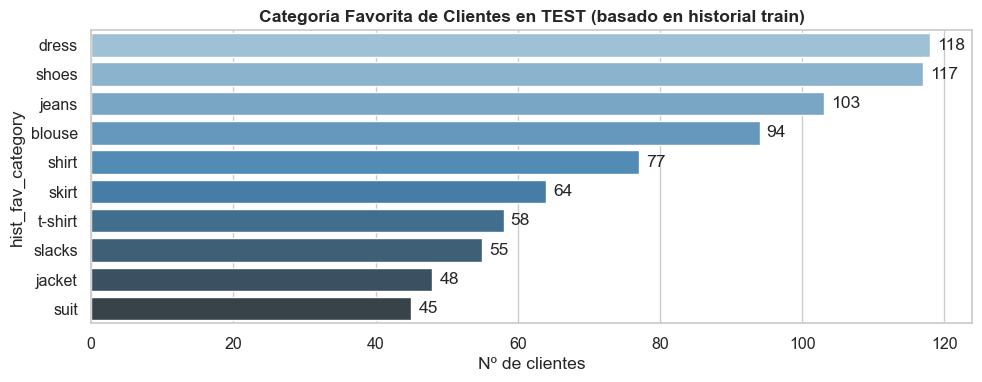

In [30]:
# ── 7.4 Categoría favorita de clientes en test ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
fav_cats = test_clients['hist_fav_category'].value_counts()
sns.barplot(x=fav_cats.values, y=fav_cats.index, ax=ax, palette='Blues_d')
ax.set_title('Categoría Favorita de Clientes en TEST (basado en historial train)',
             fontweight='bold')
ax.set_xlabel('Nº de clientes')
for p, v in zip(ax.patches, fav_cats.values):
    ax.text(p.get_width() + 1, p.get_y() + p.get_height()/2, str(v), va='center')
plt.tight_layout()
plt.savefig('fav_category_test_clients.png', dpi=120, bbox_inches='tight')
plt.show()


### 🎯 Análisis del Cold-Start

**Reto principal:** Los ítems en test son completamente nuevos — no tienen `item_avg_rating`, `item_num_ratings`, ni ninguna métrica de interacción previa. Esto elimina las features de popularidad del ítem como señal directa.

**Lo que SÍ tenemos para los ítems nuevos:**
- `item_category`, `item_price`, `item_release_date` → features del producto en sí mismo
- Distribuciones históricas de ítems similares (misma categoría, rango de precio)

**Lo que SÍ tenemos para los clientes:**
- Historial completo de compras en train → todos los 779 clientes tienen historial
- Features RFM: recencia, frecuencia, gasto promedio
- Preferencias de categoría → afinidad cliente-categoría

**Estrategia sugerida:** Modelar la probabilidad de compra en función de la **afinidad histórica cliente-categoría** y las **características del producto** (precio relativo, categoría). El modelo debe generalizar desde el comportamiento del cliente hacia nuevos productos, no desde el historial del producto.


## 8. Propuesta de Features para Modelado


In [31]:
# ── 8.1 Features de cliente (RFM + comportamiento) ─────────────────────────────
# Construimos un feature store del cliente a partir del historial en train

# Frecuencia por categoría
cat_freq = (train.groupby(['customer_id', 'item_category'])
            .size()
            .unstack(fill_value=0)
            .add_prefix('freq_cat_'))

# Gasto promedio por categoría
cat_spend = (train.groupby(['customer_id', 'item_category'])['item_price']
             .mean()
             .unstack()
             .add_prefix('avg_spend_cat_'))

# Features RFM
rfm = train.groupby('customer_id').agg(
    rfm_recency     = ('purchase_timestamp', lambda x: (CURRENT_DATE - x.max()).days),
    rfm_frequency   = ('purchase_id', 'count'),
    rfm_monetary    = ('item_price', 'mean'),
    rfm_max_spend   = ('item_price', 'max'),
    rfm_unique_cats = ('item_category', 'nunique'),
    rfm_avg_views   = ('customer_item_views', 'mean'),
    rfm_rated_ratio = ('has_rated', 'mean'),
    rfm_device_mode = ('purchase_device', lambda x: x.mode()[0]),
)

# Unir todo
customer_features = rfm.join(cat_freq).join(cat_spend)
print(f"Feature store de clientes: {customer_features.shape[0]} clientes × {customer_features.shape[1]} features")
print()
print("Primeras columnas del feature store:")
print(customer_features.columns[:20].tolist())


Feature store de clientes: 779 clientes × 28 features

Primeras columnas del feature store:
['rfm_recency', 'rfm_frequency', 'rfm_monetary', 'rfm_max_spend', 'rfm_unique_cats', 'rfm_avg_views', 'rfm_rated_ratio', 'rfm_device_mode', 'freq_cat_blouse', 'freq_cat_dress', 'freq_cat_jacket', 'freq_cat_jeans', 'freq_cat_shirt', 'freq_cat_shoes', 'freq_cat_skirt', 'freq_cat_slacks', 'freq_cat_suit', 'freq_cat_t-shirt', 'avg_spend_cat_blouse', 'avg_spend_cat_dress']


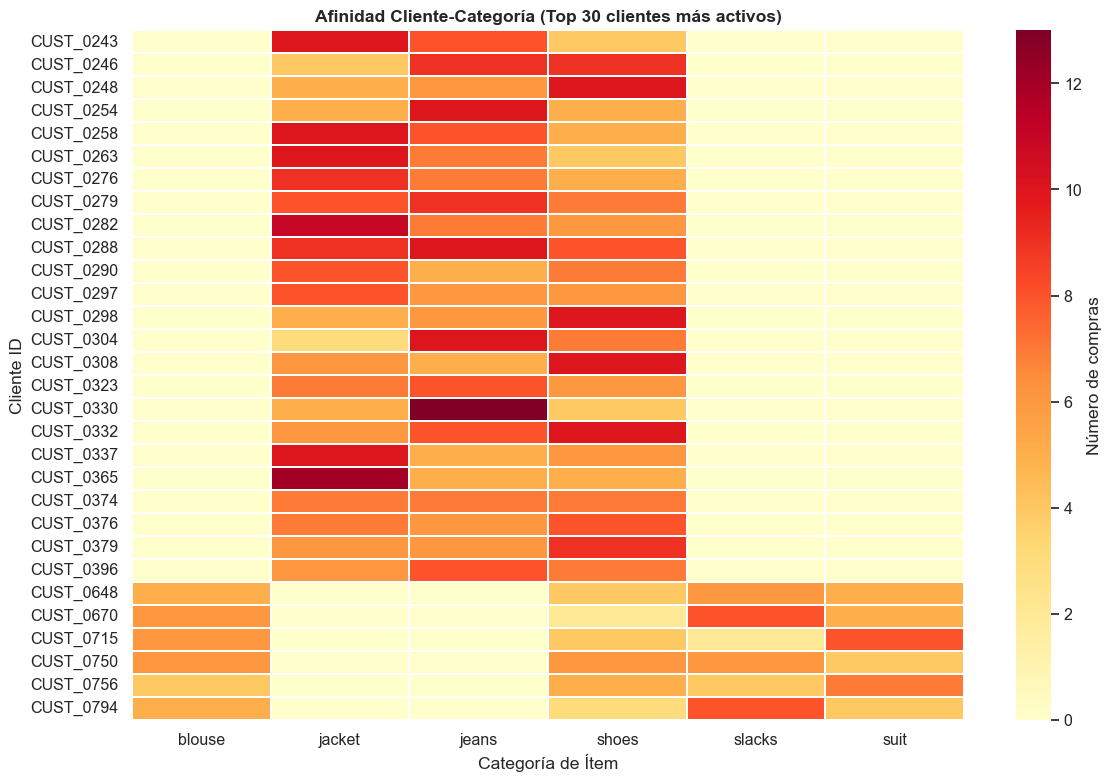

In [32]:
# ── 8.2 Visualización: Heatmap de afinidad cliente-categoría ──────────────────
# Mostrar muestra de clientes
sample_ids = train['customer_id'].value_counts().head(30).index
afinidad = (train[train['customer_id'].isin(sample_ids)]
            .groupby(['customer_id', 'item_category'])
            .size()
            .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(afinidad, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Número de compras'})
ax.set_title('Afinidad Cliente-Categoría (Top 30 clientes más activos)',
             fontweight='bold')
ax.set_xlabel('Categoría de Ítem')
ax.set_ylabel('Cliente ID')
plt.tight_layout()
plt.savefig('affinity_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


In [33]:
# ── 8.3 Resumen de features propuestos ─────────────────────────────────────────
features_catalog = {
    'Grupo': [
        'Cliente — RFM', 'Cliente — RFM', 'Cliente — RFM',
        'Cliente — Comportamiento', 'Cliente — Comportamiento', 'Cliente — Comportamiento',
        'Cliente — Demográfico', 'Cliente — Demográfico',
        'Ítem', 'Ítem', 'Ítem', 'Ítem',
        'Afinidad cliente-ítem', 'Afinidad cliente-ítem', 'Afinidad cliente-ítem',
        'Temporal',
    ],
    'Feature': [
        'rfm_recency', 'rfm_frequency', 'rfm_monetary',
        'rfm_avg_views', 'rfm_rated_ratio', 'rfm_unique_cats',
        'customer_age', 'customer_gender',
        'item_category', 'item_price', 'item_price_rank_in_category', 'item_release_dayofweek',
        'freq_cat_<category>', 'avg_spend_cat_<category>', 'price_ratio_vs_hist_avg',
        'days_since_release_at_pred',
    ],
    'Descripción': [
        'Días desde última compra', 'Nº total de compras', 'Gasto promedio',
        'Promedio de vistas antes de comprar', 'Ratio de compras con reseña', 'Categorías distintas compradas',
        'Edad calculada', 'Género (encode: male/female/unknown)',
        'Categoría del ítem nuevo (encode)', 'Precio del ítem nuevo', 'Percentil de precio dentro de su categoría', 'Día de lanzamiento',
        'Historial de compras en esa categoría', 'Gasto promedio del cliente en esa categoría', 'Precio nuevo / precio promedio histórico del cliente',
        'Cuántos días desde el lanzamiento hasta la fecha de predicción',
    ],
    'Disponible en test': [
        '✅','✅','✅','✅','✅','✅','✅','✅',
        '✅','✅','✅','✅','✅','✅','✅','✅'
    ]
}

df_features = pd.DataFrame(features_catalog)
print("Catálogo de features propuestos para el modelo:")
display(df_features)


Catálogo de features propuestos para el modelo:


,Grupo,Feature,Descripción,Disponible en test
0,Cliente — RFM,rfm_recency,Días desde última compra,✅
1,Cliente — RFM,rfm_frequency,Nº total de compras,✅
2,Cliente — RFM,rfm_monetary,Gasto promedio,✅
3,Cliente — Comportamiento,rfm_avg_views,Promedio de vistas antes de comprar,✅
4,Cliente — Comportamiento,rfm_rated_ratio,Ratio de compras con reseña,✅
5,Cliente — Comportamiento,rfm_unique_cats,Categorías distintas compradas,✅
6,Cliente — Demográfico,customer_age,Edad calculada,✅
7,Cliente — Demográfico,customer_gender,Género (encode: male/female/unknown),✅
8,Ítem,item_category,Categoría del ítem nuevo (encode),✅
9,Ítem,item_price,Precio del ítem nuevo,✅


## 9. Visualizaciones Adicionales


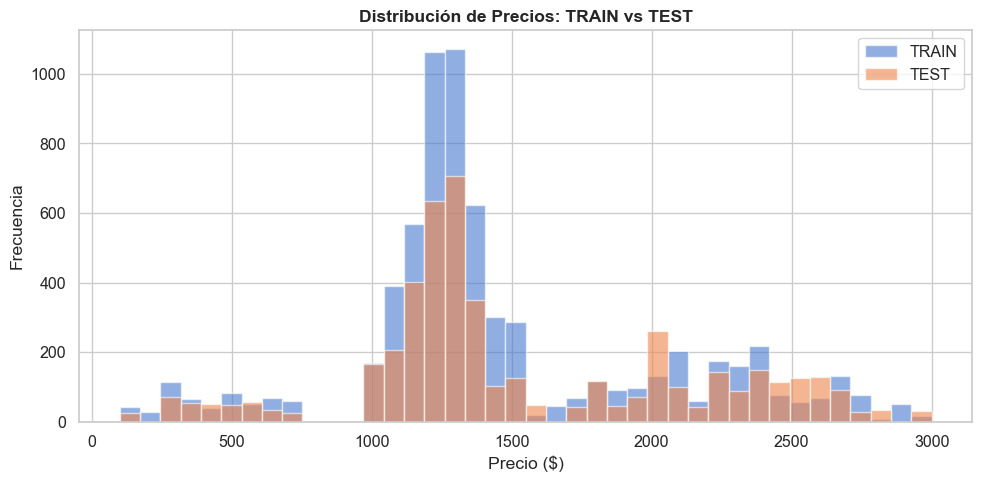

Train — precio medio: $1461.09 | mediana: $1306.57
Test  — precio medio: $1536.72 | mediana: $1319.92


In [34]:
# ── 9.1 Distribución de precios en train vs test ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train['item_price'], bins=40, alpha=0.6, label='TRAIN', color=PALETTE[0], edgecolor='white')
ax.hist(test['item_price'],  bins=40, alpha=0.6, label='TEST',  color=PALETTE[1], edgecolor='white')
ax.set_title('Distribución de Precios: TRAIN vs TEST', fontweight='bold')
ax.set_xlabel('Precio ($)')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.savefig('price_train_vs_test.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Train — precio medio: ${train['item_price'].mean():.2f} | mediana: ${train['item_price'].median():.2f}")
print(f"Test  — precio medio: ${test['item_price'].mean():.2f} | mediana: ${test['item_price'].median():.2f}")


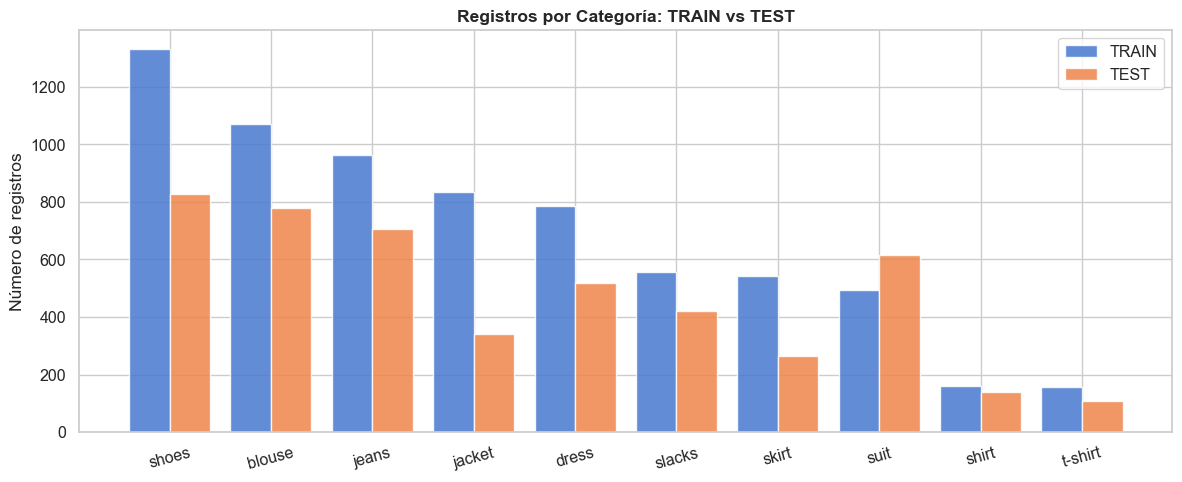

In [35]:
# ── 9.2 Compras por categoría: train vs test ───────────────────────────────────
train_cats = train['item_category'].value_counts().rename('TRAIN')
test_cats  = test['item_category'].value_counts().rename('TEST')
cats_df = pd.concat([train_cats, test_cats], axis=1).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(cats_df))
w = 0.4
ax.bar(x - w/2, cats_df['TRAIN'], width=w, label='TRAIN', color=PALETTE[0], alpha=0.85)
ax.bar(x + w/2, cats_df['TEST'],  width=w, label='TEST',  color=PALETTE[1], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(cats_df.index, rotation=15)
ax.set_title('Registros por Categoría: TRAIN vs TEST', fontweight='bold')
ax.set_ylabel('Número de registros')
ax.legend()
plt.tight_layout()
plt.savefig('categories_train_vs_test.png', dpi=120, bbox_inches='tight')
plt.show()


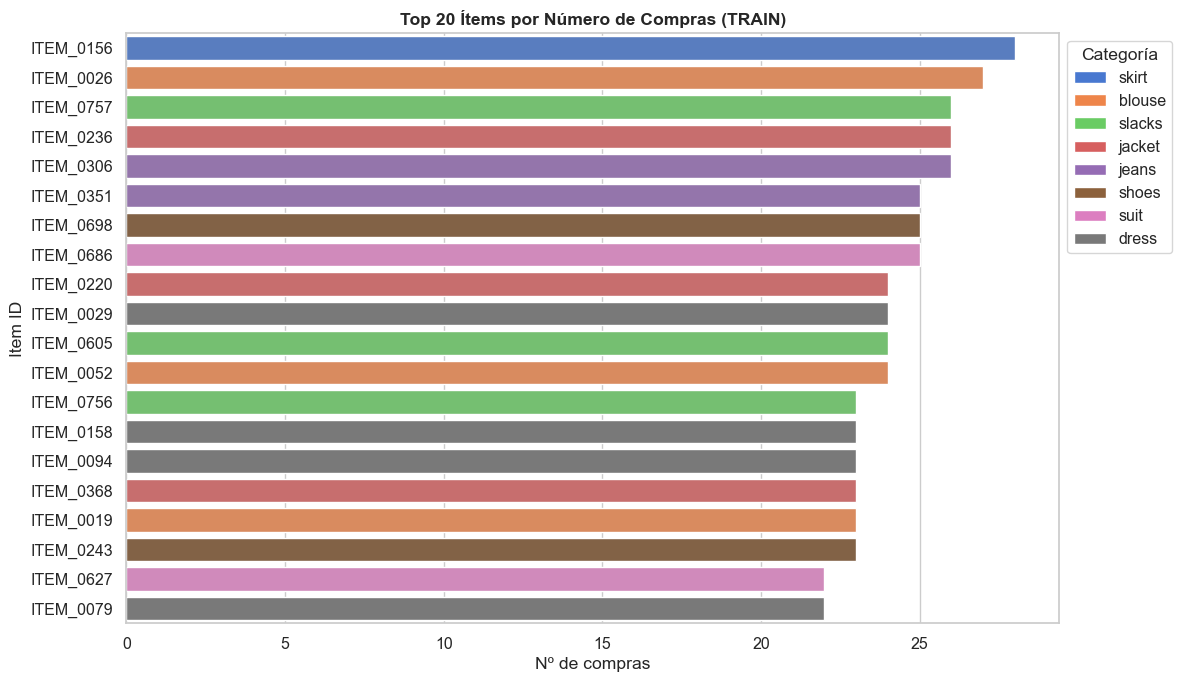

In [36]:
# ── 9.3 Top 20 ítems por número de compras ─────────────────────────────────────
top_items = train.groupby(['item_id', 'item_category'])['purchase_id'].count().reset_index()
top_items.columns = ['item_id', 'item_category', 'num_purchases']
top_items = top_items.sort_values('num_purchases', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 7))
colors_map = {cat: PALETTE[i % len(PALETTE)] for i, cat in enumerate(top_items['item_category'].unique())}
colors = [colors_map[cat] for cat in top_items['item_category']]
sns.barplot(data=top_items, y='item_id', x='num_purchases', palette=colors, ax=ax)
ax.set_title('Top 20 Ítems por Número de Compras (TRAIN)', fontweight='bold')
ax.set_xlabel('Nº de compras')
ax.set_ylabel('Item ID')
# Leyenda de categorías
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors_map.items()]
ax.legend(handles=legend_elements, title='Categoría', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('top20_items.png', dpi=120, bbox_inches='tight')
plt.show()


## 10. Conclusiones y Recomendaciones

### 🔍 Hallazgos principales del EDA

| # | Hallazgo | Implicación para el modelo |
|---|----------|--------------------------|
| 1 | **El dataset solo contiene compras positivas (label=1).** | Se requiere **negative sampling** para entrenar un clasificador binario. Estrategia sugerida: para cada cliente, muestrear ítems de su historial que NO compró. |
| 2 | **Cold-start total en test:** ningún ítem de test aparece en train. | El modelo no puede usar features de historial del ítem (`avg_rating`, `num_ratings`). Debe basarse en features del cliente + características estáticas del ítem. |
| 3 | **100 % de clientes de test tienen historial en train.** | El perfil de comportamiento del cliente está disponible para todos los casos de predicción. Features RFM son siempre computables. |
| 4 | **`customer_gender` tiene ~21 % de nulos** en train y test, de forma consistente. | Imputar con categoría `'Unknown'`. No se puede inferir el género de forma confiable. |
| 5 | **`purchase_item_rating` tiene 80 % de nulos** (no imputable). | Usar como feature binaria `has_rated` (¿dejó reseña?). El ratio histórico de reseñas por cliente es una señal de engagement. |
| 6 | **Fuerte crecimiento temporal** de compras (x250 entre feb-2025 y abr-2026). | Considerar features de temporalidad (mes del lanzamiento, tendencia reciente del cliente). Posible drift de distribución a considerar en validación. |
| 7 | **La mayoría de compras ocurren dentro de los 60 días** del lanzamiento. | Valida la ventana de predicción. Los días hasta el lanzamiento pueden ser una feature de urgencia. |
| 8 | **Las categorías en test coinciden con train.** | El encoding de categorías es directo. No hay categorías OOV (out-of-vocabulary). |

---

### 🚀 Recomendaciones para el modelo predictivo

1. **Framing del problema:** Convertir a clasificación binaria con negative sampling (relación 1:3 o 1:5 positivos:negativos por cliente).
2. **Features más prometedoras:**
   - `rfm_frequency`, `rfm_recency`, `rfm_monetary` (comportamiento global del cliente)
   - `freq_cat_<category>` (afinidad cliente-categoría específica)
   - `price_ratio_vs_hist_avg` (¿es el nuevo ítem más caro/barato que lo que suele comprar?)
   - `item_category` (algunas categorías tienen mayor conversión)
   - `customer_age`, `customer_tenure_days`
3. **Modelos sugeridos:** LightGBM o XGBoost (robustos a nulos y features categóricas), seguidos de modelos de matrix factorization si se quiere explotar la estructura usuario-ítem.
4. **Validación:** Usar validación temporal (train hasta cierta fecha, validar en el futuro) para simular el cold-start correctamente.
5. **Métrica de evaluación:** AUC-ROC o Average Precision (AP) son apropiadas para datasets desbalanceados.
